In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df=df.drop(columns=['RowNumber','CustomerId','Surname'])

In [11]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

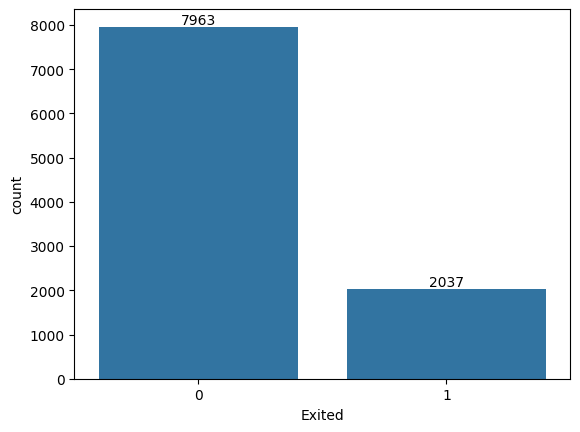

In [13]:
sb.countplot(x= 'Exited',data=df)
plt.bar_label(plt.gca().containers[0])
plt.show()

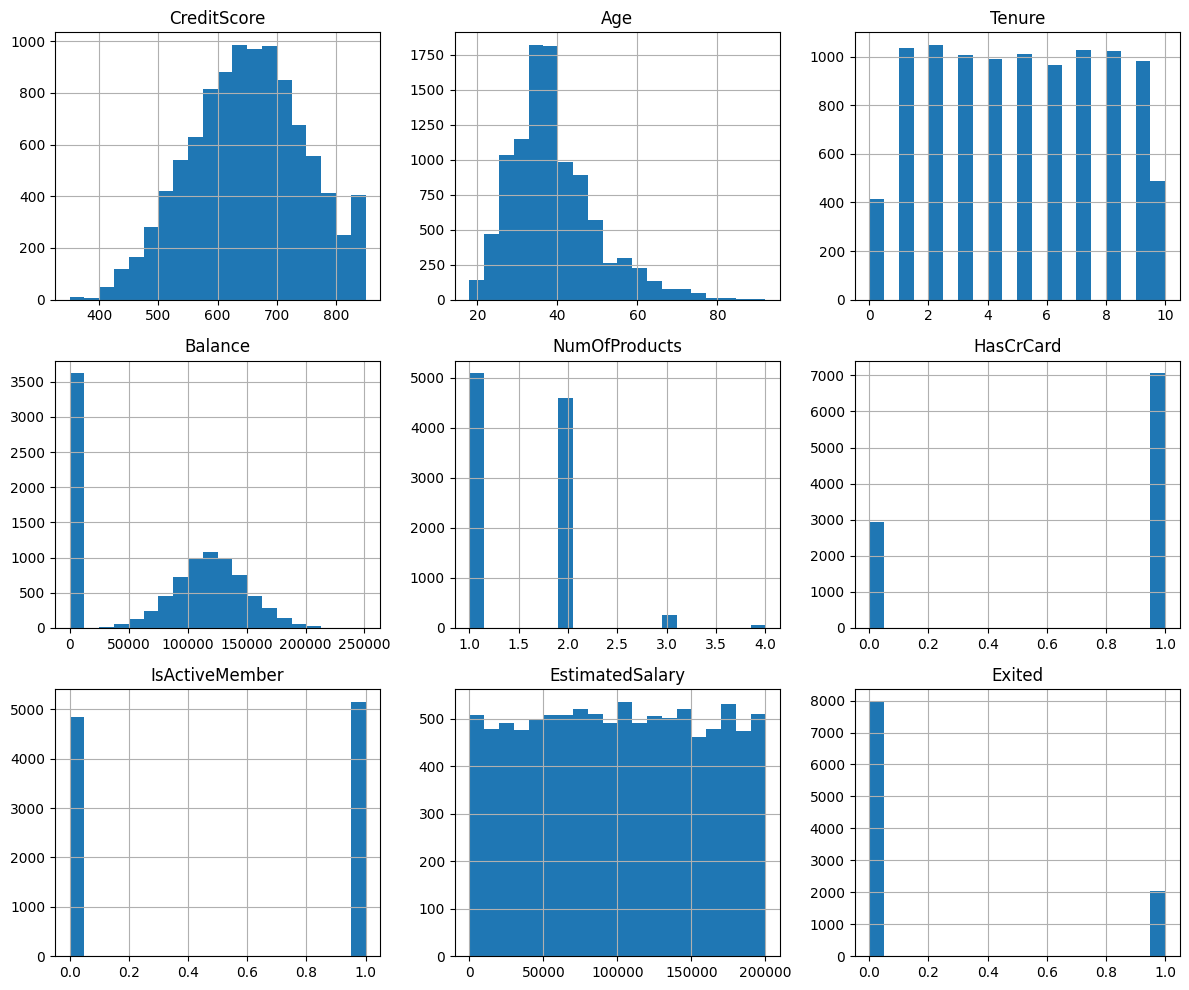

In [14]:
num_cols=df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(12,10),bins=20)
plt.tight_layout()
plt.show()


In [16]:
cat_cols=df.select_dtypes(include="object").columns
for col in cat_cols:
    print(df[col].value_counts())
    print("-"*40)

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
----------------------------------------
Gender
Male      5457
Female    4543
Name: count, dtype: int64
----------------------------------------


C:\Users\fayaz\AppData\Local\Temp\ipykernel_22184\2442035072.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include="object").columns


In [17]:
df["Geography"].unique()

<ArrowStringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [18]:
df["Gender"].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

In [19]:
df=pd.get_dummies(df,columns=["Geography"],drop_first=True)

In [20]:
from sklearn.preprocessing import LabelEncoder


le=LabelEncoder()
df['Gender']=le.fit_transform(df["Gender"])


In [ ]:
plt.Figure(figsize=(10,8))
sb.heatmap(df.corr(),cmap=)

In [10]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')